## PART B: Understanding the Dataset

Importing Library

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df=pd.read_csv(r"D:\Python_rnw\one\supervised learning\PR3\Risk_Alert_Classifier_Dataset_4600 - Risk_Alert_Classifier_Dataset_4600.csv.csv")

df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


In [3]:
df.shape

(4600, 19)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   str    
 3   region                     4498 non-null   str    
 4   employment_type            4456 non-null   str    
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m         4600 non-null   int64  
 14  fai

Target Variable

In [5]:
y= df['risk_status']

Input Features

In [6]:
x = df.drop(['risk_status'], axis=1)

In [7]:
print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

Shape of x: (4600, 18)
Shape of y: (4600,)


Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.2, 
    random_state=42
)

Missing Values

In [9]:
df.isnull().sum()

customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

Encoding Categorical Variables

In [10]:
from sklearn.preprocessing import LabelEncoder

for col in ['gender', 'region', 'employment_type']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

print(df[['gender', 'region', 'employment_type']].head())

   gender  region  employment_type
0       0       5                1
1       0       0                1
2       1       1                1
3       1       2                4
4       0       1                2


which columns are still strings.

In [11]:
print(x_train.select_dtypes(include='object').columns)

Index(['gender', 'region', 'employment_type', 'last_transaction_date'], dtype='str')


C:\Users\Admin\AppData\Local\Temp\ipykernel_15080\3463681098.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(x_train.select_dtypes(include='object').columns)


convert those columns to numbers

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in x_train.select_dtypes(include='object').columns:
    x_train[col] = le.fit_transform(x_train[col].astype(str))
    x_test[col] = le.transform(x_test[col].astype(str))

C:\Users\Admin\AppData\Local\Temp\ipykernel_15080\3578278316.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in x_train.select_dtypes(include='object').columns:


KNN Imputation

In [13]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

X_train = pd.DataFrame(
    imputer.fit_transform(x_train),
    columns=x_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(x_test),
    columns=x_test.columns
)

## PART C: Logistic Regression

Baseline Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

cm = confusion_matrix(y_test, y_pred)

print(cm)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

[[794   2]
 [  6 118]]
Accuracy: 0.991304347826087
Precision: 0.9912644927536233
Recall: 0.991304347826087
F1 Score: 0.9912439687958313


Type-1 Error(False Positive)

In [18]:
FP = cm[0,1]

Low-risk customer predicted as high-risk

Type-2 Error(False Negative)

In [20]:
FN = cm[1,0]

High risk customer predicted as low risk.
This is usually the most costly error in risk prediction.

Evaluate the Model

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.991304347826087

Confusion Matrix:
[[794   2]
 [  6 118]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       796
           1       0.98      0.95      0.97       124

    accuracy                           0.99       920
   macro avg       0.99      0.97      0.98       920
weighted avg       0.99      0.99      0.99       920



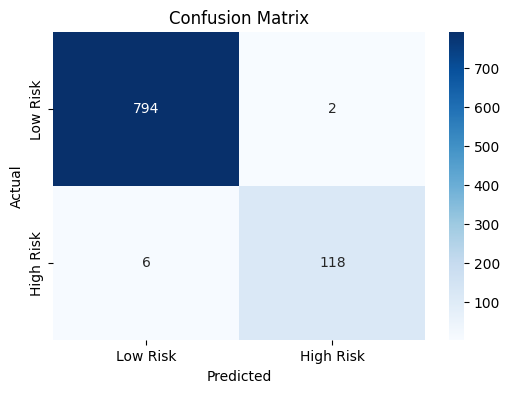

In [27]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Risk', 'High Risk'],
    yticklabels=['Low Risk', 'High Risk']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## PART D: Handling Imbalance Data

Under Sampling

In [21]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

x_under, y_under = rus.fit_resample(X_train, y_train)

Over Sampling

In [22]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

x_over, y_over = ros.fit_resample(X_train, y_train)

SMOTE

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_smote, y_smote = smote.fit_resample(X_train, y_train)

ADASYN

In [24]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)

x.ada, y.ada = adasyn.fit_resample(X_train, y_train)

C:\Users\Admin\AppData\Local\Temp\ipykernel_15080\2574119434.py:5: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  x.ada, y.ada = adasyn.fit_resample(X_train, y_train)


In [36]:
from sklearn.linear_model import LogisticRegression

model_before = LogisticRegression(max_iter=1000)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)
y_prob_before = model_before.predict_proba(X_test)[:, 1]

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Calculate Metrics

BEFORE:

In [37]:
from sklearn.metrics import recall_score, f1_score, roc_auc_score

recall_before = recall_score(y_test, y_pred_before)
f1_before = f1_score(y_test, y_pred_before)
auc_before = roc_auc_score(y_test, y_prob_before)

Train on the balanced data (example: SMOTE)

In [39]:
model_after = LogisticRegression(max_iter=1000)
model_after.fit(x_smote, y_smote)

y_pred_after = model_after.predict(X_test)
y_prob_after = model_after.predict_proba(X_test)[:, 1]

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


AFTER:

In [40]:
recall_after = recall_score(y_test, y_pred_after)
f1_after = f1_score(y_test, y_pred_after)
auc_after = roc_auc_score(y_test, y_prob_after)

Plot ROC Curve

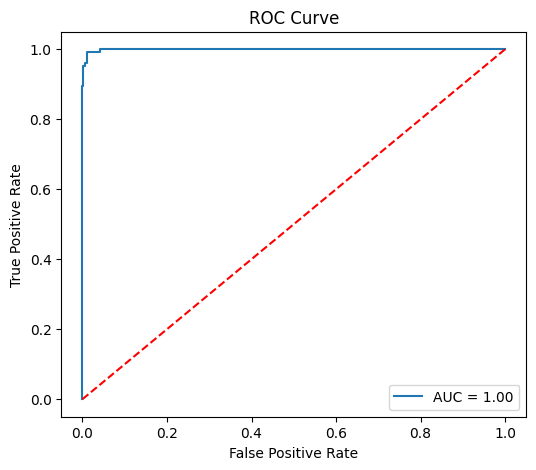

In [33]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [43]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Recall", "F1-Score", "ROC-AUC"],
    "Before Balancing": [recall_before, f1_before, auc_before],
    "After Balancing": [recall_after, f1_after, auc_after]
})

print(comparison)

     Metric  Before Balancing  After Balancing
0    Recall          0.951613         0.967742
1  F1-Score          0.967213         0.937500
2   ROC-AUC          0.999159         0.998987


## PART E: Tree-Based Models

Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt= DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

Analyzing Overfitting

In [50]:
train_pred_dt = dt.predict(X_train)

train_acc_dt = accuracy_score(y_train, train_pred_dt)
test_acc_dt = accuracy_score(y_test, y_pred_dt)

print("Training Accuracy:", train_acc_dt)
print("Testing Accuracy:", test_acc_dt) 

Training Accuracy: 1.0
Testing Accuracy: 0.9619565217391305


Random Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Comparing Decision Tree vs Random Forest

In [54]:
rf_train_pred = rf.predict(X_train)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, y_pred_rf) 

print("Decision Tree Test Accuracy:", test_acc_dt)
print("Random Forest Test Accuracy:", rf_test_acc)  

Decision Tree Test Accuracy: 0.9619565217391305
Random Forest Test Accuracy: 0.9891304347826086


Overfitting Analysis 

In [46]:
print("Train Accuracy:",
      rf.score(X_train, y_train))

print("Test Accuracy:",
      rf.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9891304347826086


## PART F: Hyperparameter Tuning

Randomeized Search CV

Decision Tree hyperparameters

In [56]:
from sklearn.model_selection import RandomizedSearchCV

dt_params = {
    'max_depth':[3, 5, 10, 15, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf':[1, 2, 4],
    'criterion':['gini', 'entropy']
}
random_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42
)

random_dt.fit(X_train, y_train)

print(random_dt.best_params_)

{'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'entropy'}


Random Forest Hyperparameters

In [57]:
rf_params = {
    'n_estimators':[100, 200, 300],
    'max_depth':[5, 10, 15, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf':[1, 2, 4]
}

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42
)

random_rf.fit(X_train, y_train)

print(random_rf.best_params_)

{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


Grid Search CV

In [58]:
from sklearn.model_selection import GridSearchCV

grid_params = {
    'n_estimators':[100, 200],
    'max_depth':[10, 15],
    'min_samples_split':[2, 5],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    grid_params,
    cv=5,
    scoring='f1'
)

grid_rf.fit(X_train, y_train)
print(grid_rf.best_params_)

{'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}


Compare Tuned vs Untuned

In [60]:
best_model = grid_rf.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Untuned Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))

Untuned Accuracy: 0.9891304347826086
Tuned Accuracy: 0.9902173913043478


## PART G: Model Evaluation & ROC Analysis

Plot ROC Curve for All Models

Logistic Regression

In [76]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_lr = model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _= roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

Decision Tree

In [65]:
y_prob_dt = dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

Random Forest

In [69]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

PLOT

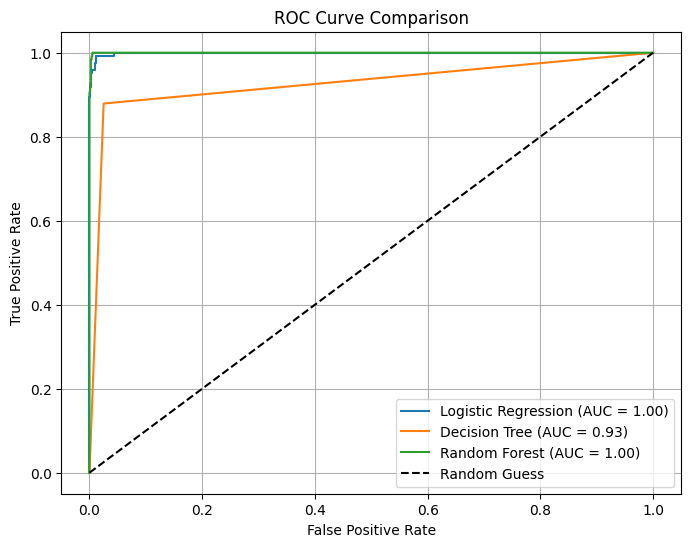

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

Compare AUC Scores

In [72]:
auc_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "AUC": [auc_lr, auc_dt, auc_rf]
})

print(auc_table)

                 Model       AUC
0  Logistic Regression  0.999159
1        Decision Tree  0.926953
2        Random Forest  0.999762
